In [1]:
#Đỗ Ngọc Lâm - B22DCCN476
# ====== CELL #1: Load raw TXT -> clean -> save CSV; create kb_healthGuide.json ======
import os, json
import numpy as np
import pandas as pd

# ========= 0) Cấu hình đường dẫn (ưu tiên Windows path; fallback sang /mnt/data nếu không thấy) =========
RAW_PATH_WIN = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\knb-lter-cdr.496.9\e267_Data on age, gender, height, weight, activity levels for each household member..txt"
RAW_PATHS_CANDIDATE = [
    RAW_PATH_WIN,
    "/mnt/data/e267_Data on age, gender, height, weight, activity levels for each household member..txt",
    "e267_Data on age, gender, height, weight, activity levels for each household member..txt"
]

raw_path = None
for p in RAW_PATHS_CANDIDATE:
    if os.path.exists(p):
        raw_path = p
        break
if raw_path is None:
    raise FileNotFoundError(
        "Không tìm thấy file TXT. Hãy kiểm tra lại đường dẫn hoặc upload file vào /mnt/data rồi chạy lại."
    )

# Thư mục đích (nếu chạy Windows dùng thư mục bài tập; nếu không thì lưu cùng notebook)
OUT_DIR_WIN = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4"
OUT_DIR = OUT_DIR_WIN if os.path.isdir(os.path.dirname(OUT_DIR_WIN)) or os.path.exists(OUT_DIR_WIN) else "./assignment_4_out"
os.makedirs(OUT_DIR, exist_ok=True)

CSV_PATH = os.path.join(OUT_DIR, "data_4.2.csv")
KB_PATH  = os.path.join(OUT_DIR, "kb_healthGuide.json")

print(f"[INFO] Raw TXT path: {raw_path}")
print(f"[INFO] Output folder: {OUT_DIR}")

# ========= 1) Đọc file thô (tab-delimited) =========
df_raw = pd.read_csv(raw_path, sep="\t")
# Kỳ vọng các cột: HH_ID, Member_Age_Orig, Member_ID, Member_Gender_Orig, HEIGHT, WEIGHT, Mod_act, Vig_act
print("[INFO] Raw columns:", list(df_raw.columns))

# ========= 2) Hàm chuyển HEIGHT feet.inches -> cm =========
# Ví dụ "5.11" = 5 feet 11 inches; "5.7" = 5 feet 7 inches; nếu không có dấu chấm => inches=0
def feet_inches_to_cm(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s == "":
        return np.nan
    if "." in s:
        a, b = s.split(".", 1)
        try:
            feet = int(a)
        except:
            return np.nan
        # phần sau nên là số nguyên inches (0..11). Nếu không phải int thuần, cố gắng parse float.
        try:
            inches = int(b)
        except:
            try:
                inches = int(round(float("0."+b) * 12))
            except:
                return np.nan
    else:
        try:
            feet = int(s)
            inches = 0
        except:
            return np.nan
    return feet*30.48 + inches*2.54

# ========= 3) Hàm chuyển WEIGHT pounds -> kg =========
LB_TO_KG = 0.45359237
def pounds_to_kg(val):
    if pd.isna(val) or str(val).strip()=="":
        return np.nan
    try:
        return float(val) * LB_TO_KG
    except:
        return np.nan

# ========= 4) Tạo dataframe sạch (columns chuẩn) =========
df = pd.DataFrame({
    "age": df_raw.get("Member_Age_Orig"),
    "gender": df_raw.get("Member_Gender_Orig"),  # 1=Male, 2=Female (dataset gốc)
    "height_cm": df_raw.get("HEIGHT").apply(feet_inches_to_cm) if "HEIGHT" in df_raw.columns else np.nan,
    "weight_kg": df_raw.get("WEIGHT").apply(pounds_to_kg) if "WEIGHT" in df_raw.columns else np.nan,
    "mod_act_hr_per_week": df_raw.get("Mod_act"),
    "vig_act_hr_per_week": df_raw.get("Vig_act"),
})

# Ép kiểu số hợp lệ cho các cột hoạt động, tuổi, giới
for c in ["age","gender","mod_act_hr_per_week","vig_act_hr_per_week"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Loại bản ghi thiếu tối thiểu height/weight/age
df = df.dropna(subset=["age","height_cm","weight_kg"]).reset_index(drop=True)

# Giới tính: map thành chuỗi cho dễ đọc/one-hot sau này (1->Male, 2->Female, còn lại Unknown)
df["gender"] = df["gender"].map({1:"Male", 2:"Female"}).fillna("Unknown")

# ========= 5) Lưu CSV =========
df.to_csv(CSV_PATH, index=False, encoding="utf-8")
print(f"[DONE] Saved cleaned dataset to: {CSV_PATH}")
print(df.head(5))

# ========= 6) Tạo Knowledge Base (nếu chưa có) =========
DEFAULT_KB = {
    "bmi_categories": {
        "underweight": "BMI < 18.5",
        "normal": "18.5 ≤ BMI < 25",
        "overweight": "BMI ≥ 25"
    },
    "advice": {
        "underweight": [
            "Tăng năng lượng lành mạnh: thêm ngũ cốc nguyên hạt, các loại hạt, dầu tốt.",
            "Ăn đủ đạm (thịt nạc, trứng, sữa chua, đậu).",
            "Chia nhỏ bữa, thêm snack giàu dinh dưỡng.",
            "Khám chuyên khoa nếu sụt cân nhanh/khó tăng cân."
        ],
        "normal": [
            "Duy trì khẩu phần cân bằng, nhiều rau quả (≥400 g/ngày).",
            "Hoạt động thể lực ≥150 phút/tuần mức vừa + 2 ngày/tuần tăng cơ.",
            "Hạn chế nước ngọt có đường, đồ siêu chế biến.",
            "Ngủ đủ giấc, quản lý stress."
        ],
        "overweight": [
            "Đặt mục tiêu giảm cân thực tế; theo dõi khẩu phần/calo.",
            "Tăng rau quả; giảm đường, muối, chất béo bão hoà.",
            "Vận động ≥150 phút/tuần + 2 ngày/tuần tăng cơ.",
            "Tư vấn dinh dưỡng y khoa nếu cần."
        ]
    },
    "sources": [
        "WHO/CDC BMI cutoffs; WHO healthy diet; CDC/WHO physical activity"
    ]
}
if not os.path.exists(KB_PATH):
    with open(KB_PATH, "w", encoding="utf-8") as f:
        json.dump(DEFAULT_KB, f, ensure_ascii=False, indent=2)
    print(f"[DONE] Created KB at: {KB_PATH}")
else:
    print(f"[INFO] KB exists at: {KB_PATH}")


[INFO] Raw TXT path: C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\knb-lter-cdr.496.9\e267_Data on age, gender, height, weight, activity levels for each household member..txt
[INFO] Output folder: C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4
[INFO] Raw columns: ['HH_ID', 'Member_Age_Orig', 'Member_ID', 'Member_Gender_Orig', 'HEIGHT', 'WEIGHT', 'Mod_act', 'Vig_act']
[DONE] Saved cleaned dataset to: C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\data_4.2.csv
    age  gender  height_cm  weight_kg  mod_act_hr_per_week  \
0  37.0    Male     154.94  86.182550                 32.0   
1  37.0  Female     165.10  77.110703                 30.0   
2  28.0    Male     180.34  86.182550                 20.0   
3  26.0  Female     165.10  63.502932                 10.0   
4  47.0    Male     170.18  70.306817                 18.0   

   vig_act_hr_per_week  
0                  NaN  
1                  2.0  
2                 30.0  
3                 15.0  
4                

In [2]:
#Đỗ Ngọc Lâm - B22DCCN476
data = pd.read_csv("data_4.2.csv")
data.head(100)

,age,gender,height_cm,weight_kg,mod_act_hr_per_week,vig_act_hr_per_week
0,37.0,Male,154.94,86.182550,32.0,NaN
1,37.0,Female,165.10,77.110703,30.0,2.0
2,28.0,Male,180.34,86.182550,20.0,30.0
3,26.0,Female,165.10,63.502932,10.0,15.0
4,47.0,Male,170.18,70.306817,18.0,10.0
...,...,...,...,...,...,...
95,50.0,Female,160.02,54.431084,30.0,NaN
96,22.0,Male,182.88,81.646627,50.0,NaN
97,53.0,Male,182.88,154.221406,4.0,0.0
98,50.0,Female,160.02,82.553811,2.0,0.0


Phân phối nhãn:
label
overweight     2998
normal         2242
underweight     589
Name: count, dtype: int64


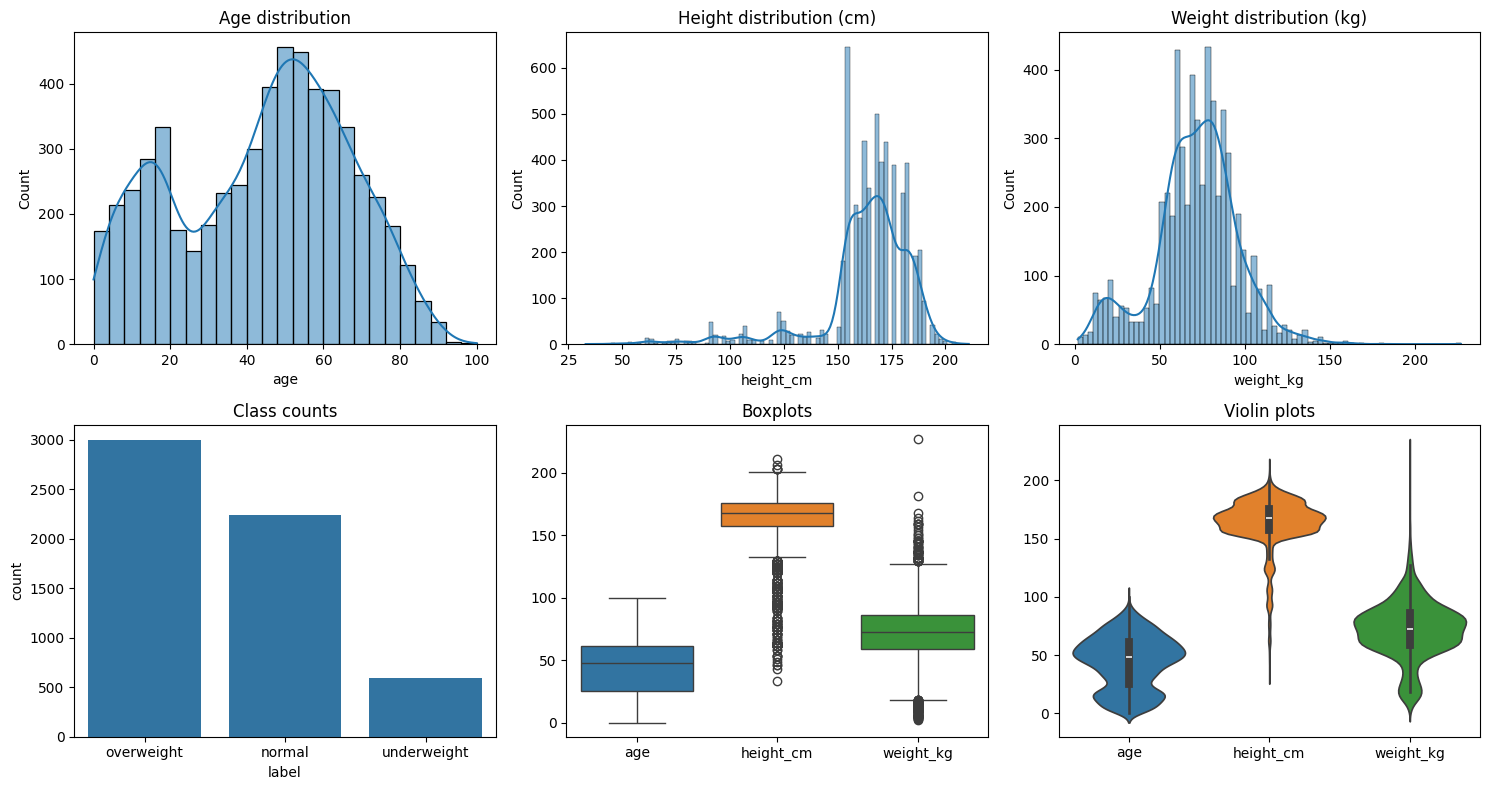

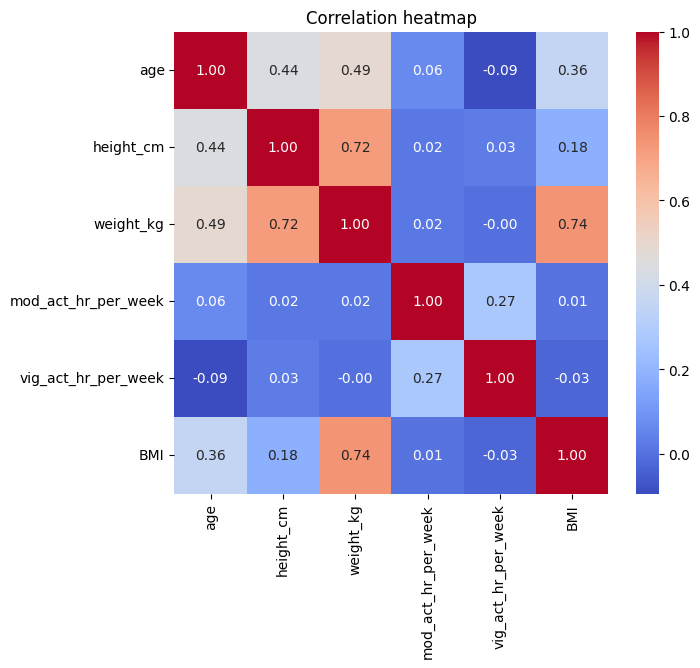

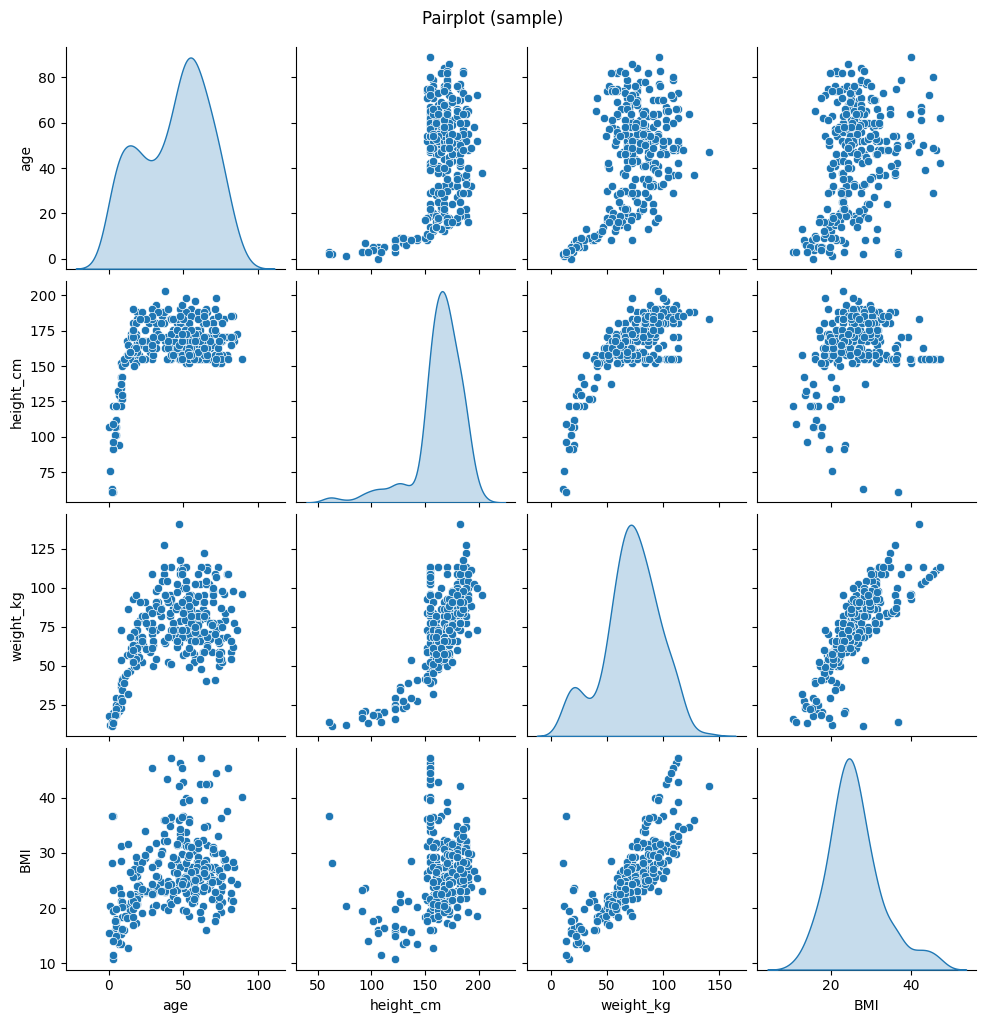


[KQ 5 mô hình ML cơ bản]
          model       acc       mae       mse      rmse
4  RandomForest  0.956261  0.044597  0.046312  0.215203
0        LogReg  0.949400  0.052316  0.055746  0.236106
1       SVM-RBF  0.941681  0.063465  0.073756  0.271581
3  DecisionTree  0.935678  0.065180  0.066895  0.258641
2           KNN  0.887650  0.114923  0.120069  0.346509


<Figure size 480x450 with 0 Axes>

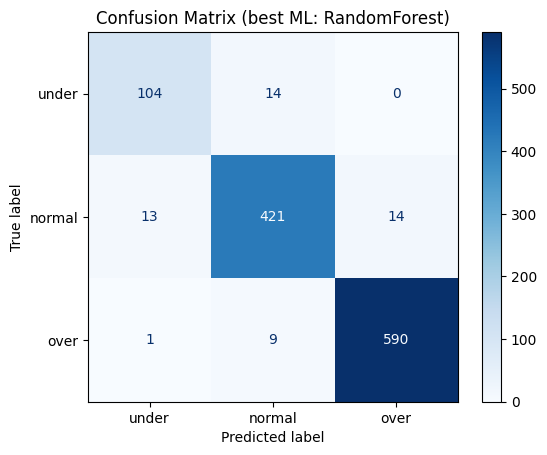


[KQ mô hình DL (CNN/RNN/LSTM)]
  model       acc       mae       mse      rmse
1   RNN  0.981990  0.018010  0.018010  0.134202
0   CNN  0.935678  0.066895  0.072041  0.268405
2  LSTM  0.668096  0.345626  0.373070  0.610795

[BẢNG SO SÁNH TỔNG HỢP]
          model       acc       mae       mse      rmse type
5           RNN  0.981990  0.018010  0.018010  0.134202   DL
0  RandomForest  0.956261  0.044597  0.046312  0.215203   ML
1        LogReg  0.949400  0.052316  0.055746  0.236106   ML
2       SVM-RBF  0.941681  0.063465  0.073756  0.271581   ML
6           CNN  0.935678  0.066895  0.072041  0.268405   DL
3  DecisionTree  0.935678  0.065180  0.066895  0.258641   ML
4           KNN  0.887650  0.114923  0.120069  0.346509   ML
7          LSTM  0.668096  0.345626  0.373070  0.610795   DL


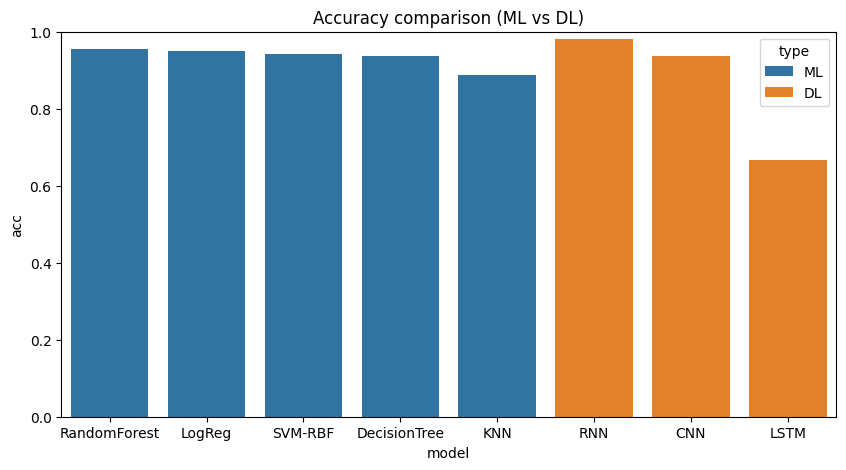

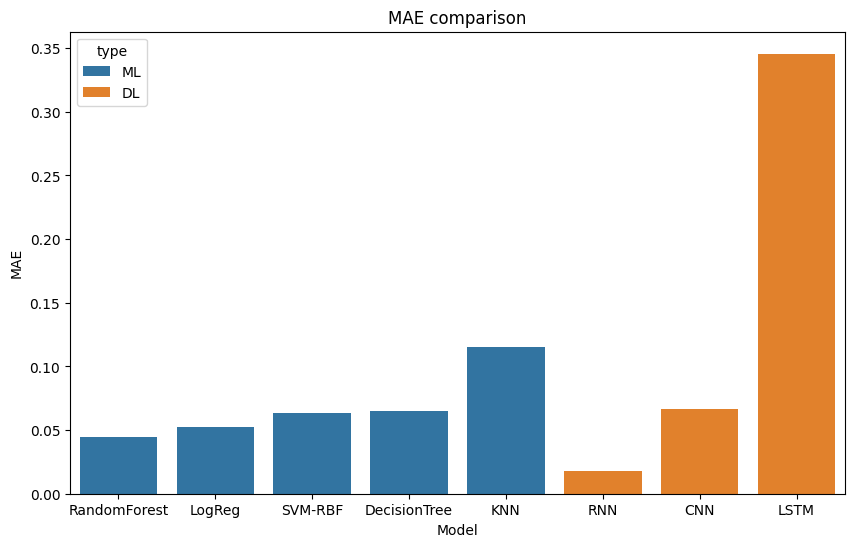

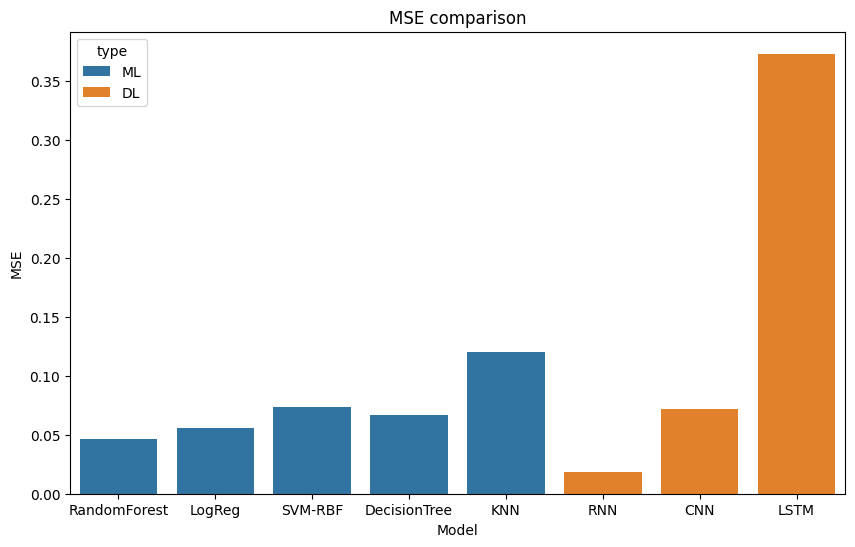

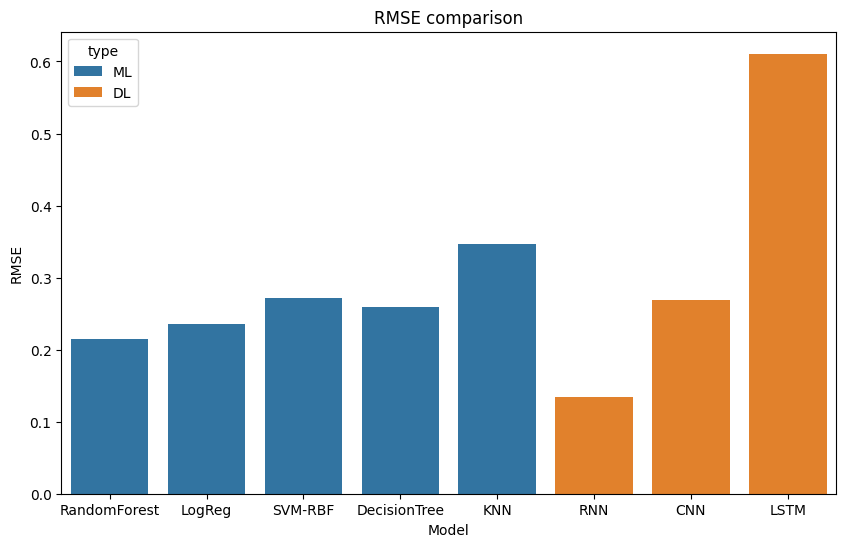

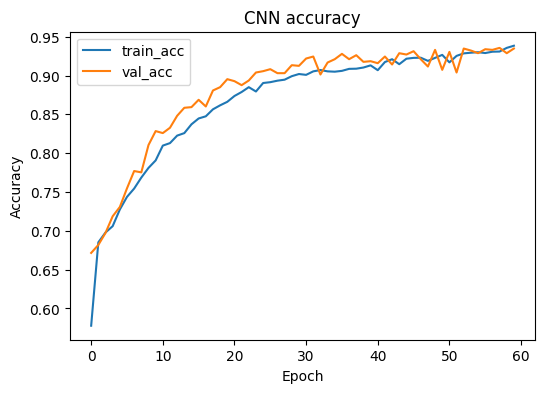

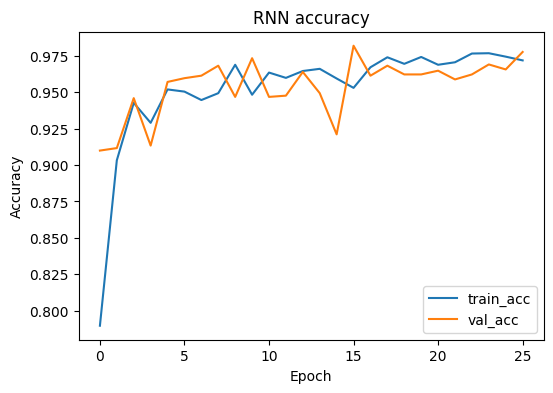

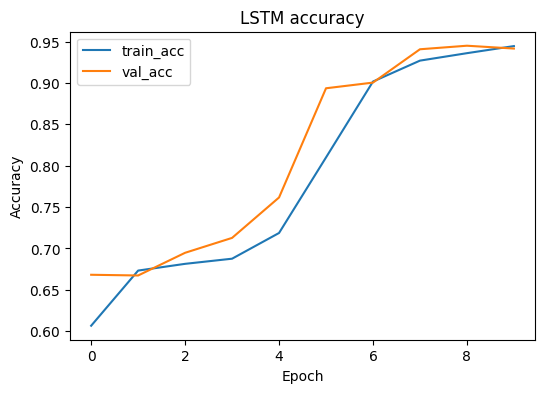


[DEPLOY] Best model: DL - RNN | acc=0.9820


Nhập giới tính (Male/Female):  Female
Nhập tuổi:  18
Nhập chiều cao (cm):  163
Nhập cân nặng (kg):  57
Giờ hoạt động mức vừa/tuần (mặc định 0):  2
Giờ hoạt động mức mạnh/tuần (mặc định 0):  1



[KẾT QUẢ DỰ ĐOÁN & TƯ VẤN]
{
  "input": {
    "gender": "Female",
    "age": 18,
    "height_cm": 163.0,
    "weight_kg": 57.0,
    "mod_act_hr_per_week": 2.0,
    "vig_act_hr_per_week": 1.0
  },
  "BMI": 21.5,
  "rule_label": "normal",
  "model_label": "normal",
  "advice": [
    "Duy trì chế độ ăn cân bằng, nhiều rau củ quả (≥400 g/ngày).",
    "Hoạt động thể lực: ≥150 phút/tuần mức vừa hoặc ≥75 phút/tuần mức mạnh; tập tăng cơ ≥2 ngày/tuần.",
    "Hạn chế đồ uống có đường và thực phẩm siêu chế biến.",
    "Duy trì thói quen ngủ đủ giấc, quản lý stress."
  ]
}


In [3]:
#Đỗ Ngọc Lâm - B22DCCN476
# =========================
# (b)→(g) ALL-IN-ONE cho data_4.2.csv (cột: age, gender, height_cm, weight_kg, mod_act_hr_per_week, vig_act_hr_per_week)
# =========================
import os, json, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, ConfusionMatrixDisplay

# 5 mô hình ML cơ bản
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -------------------------
# ĐƯỜNG DẪN
# -------------------------
DATA_DIR = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4"  # đổi nếu cần
DATA_PATH = os.path.join(DATA_DIR, "data_4.2.csv")
KB_PATH   = os.path.join(DATA_DIR, "kb_healthGuide.json")
assert os.path.exists(DATA_PATH), "Chưa thấy data_4.2.csv — hãy đặt file đúng đường dẫn!"

# -------------------------
# (b) Show the distribution
# -------------------------
df = pd.read_csv(DATA_PATH)

# Điền NA hoạt động thể lực (nếu có) bằng 0
for col in ["mod_act_hr_per_week", "vig_act_hr_per_week"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Tính BMI và nhãn (gộp obesity vào 'overweight' theo đề)
def bmi_from_hw(h_cm, w_kg):
    return w_kg / ((h_cm/100.0)**2)

df["BMI"] = bmi_from_hw(df["height_cm"].astype(float), df["weight_kg"].astype(float))

def bmi_label(bmi):
    if bmi < 18.5:
        return "underweight"
    elif bmi < 25:
        return "normal"
    else:
        return "overweight"  # gộp >=25 (bao gồm obese) vào overweight
df["label"] = df["BMI"].apply(bmi_label)

print("Phân phối nhãn:")
print(df["label"].value_counts())

# Hiển thị phân phối (>=5 loại biểu đồ)
plt.figure(figsize=(15,8))
plt.subplot(2,3,1); sns.histplot(df["age"], kde=True); plt.title("Age distribution")
plt.subplot(2,3,2); sns.histplot(df["height_cm"], kde=True); plt.title("Height distribution (cm)")
plt.subplot(2,3,3); sns.histplot(df["weight_kg"], kde=True); plt.title("Weight distribution (kg)")
plt.subplot(2,3,4); sns.countplot(data=df, x="label"); plt.title("Class counts")
plt.subplot(2,3,5); sns.boxplot(data=df[["age","height_cm","weight_kg"]]); plt.title("Boxplots")
plt.subplot(2,3,6); sns.violinplot(data=df[["age","height_cm","weight_kg"]]); plt.title("Violin plots")
plt.tight_layout()
plt.show()

# Heatmap tương quan
plt.figure(figsize=(7,6))
corr_cols = ["age","height_cm","weight_kg","mod_act_hr_per_week","vig_act_hr_per_week","BMI"]
corr_cols = [c for c in corr_cols if c in df.columns]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

# Pairplot (một loại hình nữa)
sns.pairplot(df[["age","height_cm","weight_kg","BMI"]].sample(min(300,len(df))), diag_kind="kde")
plt.suptitle("Pairplot (sample)", y=1.02)
plt.show()


# --------------------------------------------------------
# Chuẩn bị dữ liệu cho học máy
# --------------------------------------------------------
# Dùng đúng các cột có trong dataset của bạn
feature_cols = ["gender","age","height_cm","weight_kg","mod_act_hr_per_week","vig_act_hr_per_week"]
feature_cols = [c for c in feature_cols if c in df.columns]  # đề phòng thiếu

X = df[feature_cols].copy()
y = df["label"].map({"underweight":0, "normal":1, "overweight":2}).astype(int)  # encode 3 lớp thành 0/1/2

# Tách cat/num theo cột thực tế
cat_cols = [c for c in ["gender"] if c in X.columns]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=7)

preprocess = ColumnTransformer([
    ("ohe", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("scaler", StandardScaler(), num_cols)
])

# --------------------------------------------------------
# (c) 5 mô hình ML cơ bản
# --------------------------------------------------------
ml_models = {
    "LogReg": LogisticRegression(max_iter=300),
    "SVM-RBF": SVC(kernel="rbf", probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "DecisionTree": DecisionTreeClassifier(max_depth=6, random_state=7),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=7)
}

ml_results, ml_pipelines = [], {}

for name, model in ml_models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = math.sqrt(mse)
    ml_results.append({"model": name, "acc": acc, "mae": mae, "mse": mse, "rmse": rmse})
    ml_pipelines[name] = pipe

ml_df = pd.DataFrame(ml_results).sort_values("acc", ascending=False)
print("\n[KQ 5 mô hình ML cơ bản]")
print(ml_df)

# Confusion matrix cho mô hình ML tốt nhất
best_ml_name = ml_df.iloc[0]["model"]
best_ml = ml_pipelines[best_ml_name]
y_pred_best_ml = best_ml.predict(X_val)

plt.figure(figsize=(4.8,4.5))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_best_ml, display_labels=["under","normal","over"], cmap="Blues")
plt.title(f"Confusion Matrix (best ML: {best_ml_name})")
plt.show()


# --------------------------------------------------------
# (d) 3 mô hình DL: CNN, RNN, LSTM — mỗi mô hình 5 tầng
#  Dữ liệu tabular -> preprocess -> mảng -> reshape (samples, steps=n_features, channels=1)
# --------------------------------------------------------
X_train_t = preprocess.fit_transform(X_train)
X_val_t   = preprocess.transform(X_val)

n_features = X_train_t.shape[1]
num_classes = 3

# chuyển sang dense nếu là sparse
def to_dense(a):
    return np.asarray(a.todense() if hasattr(a, "todense") else a)

X_train_seq = to_dense(X_train_t).reshape(-1, n_features, 1)
X_val_seq   = to_dense(X_val_t).reshape(-1, n_features, 1)

y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val, num_classes)

def build_cnn(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="cnn_1d")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_rnn(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.SimpleRNN(64, return_sequences=False)(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="rnn_simple")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_lstm(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=False)(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="lstm_1")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

cnn  = build_cnn((n_features,1), num_classes)
rnn  = build_rnn((n_features,1), num_classes)
lstm = build_lstm((n_features,1), num_classes)

early = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_accuracy")

hist_cnn  = cnn.fit(X_train_seq, y_train_oh, validation_data=(X_val_seq, y_val_oh),
                    epochs=60, batch_size=64, verbose=0, callbacks=[early])
hist_rnn  = rnn.fit(X_train_seq, y_train_oh, validation_data=(X_val_seq, y_val_oh),
                    epochs=60, batch_size=64, verbose=0, callbacks=[early])
hist_lstm = lstm.fit(X_train_seq, y_train_oh, validation_data=(X_val_seq, y_val_oh),
                     epochs=60, batch_size=64, verbose=0, callbacks=[early])

def eval_dl(model, name):
    y_pred_prob = model.predict(X_val_seq, verbose=0)
    y_pred = y_pred_prob.argmax(axis=1)
    acc = accuracy_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = math.sqrt(mse)
    return {"model": name, "acc": acc, "mae": mae, "mse": mse, "rmse": rmse}

dl_results = [eval_dl(m, nm) for m, nm in [(cnn,"CNN"), (rnn,"RNN"), (lstm,"LSTM")]]
dl_df = pd.DataFrame(dl_results).sort_values("acc", ascending=False)
print("\n[KQ mô hình DL (CNN/RNN/LSTM)]")
print(dl_df)

# So sánh tất cả mô hình (c & d)
all_df = pd.concat([ml_df.assign(type="ML"), dl_df.assign(type="DL")], ignore_index=True)
print("\n[BẢNG SO SÁNH TỔNG HỢP]")
print(all_df.sort_values(["acc","type"], ascending=[False, True]))

# (e) Vẽ biểu đồ so sánh metrics
plt.figure(figsize=(10,5))
sns.barplot(data=all_df, x="model", y="acc", hue="type")
plt.title("Accuracy comparison (ML vs DL)")
plt.ylim(0,1); plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x="model", y="mae", hue="type")
plt.title("MAE comparison"); plt.ylabel("MAE"); plt.xlabel("Model"); plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x="model", y="mse", hue="type")
plt.title("MSE comparison"); plt.ylabel("MSE"); plt.xlabel("Model"); plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x="model", y="rmse", hue="type")
plt.title("RMSE comparison"); plt.ylabel("RMSE"); plt.xlabel("Model"); plt.show()

# Learning curves
def plot_history(h, title):
    plt.figure(figsize=(6,4))
    plt.plot(h.history["accuracy"], label="train_acc")
    plt.plot(h.history["val_accuracy"], label="val_acc")
    plt.title(title); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()
plot_history(hist_cnn, "CNN accuracy")
plot_history(hist_rnn, "RNN accuracy")
plot_history(hist_lstm, "LSTM accuracy")

# --------------------------------------------------------
# (g) Deploy best model + Health Guide (KB JSON)
# --------------------------------------------------------

# 1) Chọn mô hình tốt nhất theo accuracy (ưu tiên DL, nếu bằng thì lấy DL)
best_row = all_df.sort_values(["acc","type"], ascending=[False, True]).iloc[0]
best_name = best_row["model"]
best_type = best_row["type"]

if best_type == "ML":
    best_model = ml_pipelines[best_name]
    use_dl = False
else:
    m = {"CNN": cnn, "RNN": rnn, "LSTM": lstm}
    best_model = m[best_name]
    use_dl = True

print(f"\n[DEPLOY] Best model: {best_type} - {best_name} | acc={best_row['acc']:.4f}")

# 2) Knowledge Base: nếu chưa có file, tạo với nội dung chuẩn (WHO/CDC)
DEFAULT_KB = {
    "bmi_categories": {
        "underweight": "BMI < 18.5",
        "normal": "18.5 ≤ BMI < 25",
        "overweight": "BMI ≥ 25"
    },
    "advice": {
        "underweight": [
            "Tăng năng lượng lành mạnh: thêm ngũ cốc nguyên hạt, các loại hạt và dầu lành mạnh.",
            "Ăn đủ đạm (thịt nạc, trứng, sữa chua, đậu).",
            "Chia nhỏ bữa, thêm snack giàu dinh dưỡng.",
            "Theo dõi cân nặng, giấc ngủ; khám chuyên khoa nếu sụt cân nhanh."
        ],
        "normal": [
            "Duy trì chế độ ăn cân bằng, nhiều rau củ quả (≥400 g/ngày).",
            "Hoạt động thể lực: ≥150 phút/tuần mức vừa hoặc ≥75 phút/tuần mức mạnh; tập tăng cơ ≥2 ngày/tuần.",
            "Hạn chế đồ uống có đường và thực phẩm siêu chế biến.",
            "Duy trì thói quen ngủ đủ giấc, quản lý stress."
        ],
        "overweight": [
            "Thiết lập mục tiêu giảm cân thực tế, theo dõi khẩu phần và calo.",
            "Tăng rau củ quả; giảm đường, muối, chất béo bão hòa.",
            "Hoạt động thể lực theo khuyến nghị (≥150 phút/tuần + 2 ngày tăng cơ).",
            "Ngủ đủ, quản lý stress; cân nhắc tư vấn dinh dưỡng y khoa nếu cần."
        ]
    },
    "sources": [
        "WHO BMI cutoffs, CDC BMI categories",
        "WHO healthy diet (≥400g rau quả/ngày)",
        "CDC & WHO physical activity (≥150 phút/tuần)"
    ]
}

os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(KB_PATH):
    with open(KB_PATH, "w", encoding="utf-8") as f:
        json.dump(DEFAULT_KB, f, ensure_ascii=False, indent=2)

with open(KB_PATH, "r", encoding="utf-8") as f:
    KB = json.load(f)

# 3) Hàm suy luận + tư vấn
#    Đầu vào: gender, age, height(cm), weight(kg), (optional) giờ hoạt động
def predict_and_guide(gender: str, age: int, height_cm: float, weight_kg: float,
                      mod_act_hr_per_week: float = 0.0, vig_act_hr_per_week: float = 0.0):
    bmi = weight_kg / ((height_cm/100.0)**2)
    if bmi < 18.5:
        lbl_rule = "underweight"
    elif bmi < 25:
        lbl_rule = "normal"
    else:
        lbl_rule = "overweight"

    X_new = pd.DataFrame([{
        "gender": gender,
        "age": age,
        "height_cm": height_cm,
        "weight_kg": weight_kg,
        "mod_act_hr_per_week": mod_act_hr_per_week if "mod_act_hr_per_week" in X.columns else 0.0,
        "vig_act_hr_per_week": vig_act_hr_per_week if "vig_act_hr_per_week" in X.columns else 0.0
    }])[feature_cols]  # đúng thứ tự/ tập cột đang dùng

    if use_dl:
        X_new_t = preprocess.transform(X_new)
        X_new_seq = np.asarray(X_new_t.todense() if hasattr(X_new_t, "todense") else X_new_t).reshape(1, -1, 1)
        probs = best_model.predict(X_new_seq, verbose=0)[0]
        pred_id = int(np.argmax(probs))
    else:
        probs = None
        pred_id = int(best_model.predict(X_new)[0])

    inv_map = {0:"underweight", 1:"normal", 2:"overweight"}
    pred_lbl = inv_map[pred_id]

    advice_list = KB.get("advice", {}).get(pred_lbl, [])
    result = {
        "input": {
            "gender": gender, "age": age, "height_cm": height_cm, "weight_kg": weight_kg,
            "mod_act_hr_per_week": mod_act_hr_per_week, "vig_act_hr_per_week": vig_act_hr_per_week
        },
        "BMI": round(bmi, 1),
        "rule_label": lbl_rule,
        "model_label": pred_lbl,
        "advice": advice_list
    }
    return result

# Demo triển khai
gender = input("Nhập giới tính (Male/Female): ")
age = int(input("Nhập tuổi: "))
height_cm = float(input("Nhập chiều cao (cm): "))
weight_kg = float(input("Nhập cân nặng (kg): "))
mod_act = float(input("Giờ hoạt động mức vừa/tuần (mặc định 0): ") or 0)
vig_act = float(input("Giờ hoạt động mức mạnh/tuần (mặc định 0): ") or 0)

result = predict_and_guide(gender=gender, age=age, height_cm=height_cm, weight_kg=weight_kg,
                           mod_act_hr_per_week=mod_act, vig_act_hr_per_week=vig_act)

print("\n[KẾT QUẢ DỰ ĐOÁN & TƯ VẤN]")
print(json.dumps(result, ensure_ascii=False, indent=2))
